---
numbering: false
---

# 7.1. Regression using Linear Algebra

At times, Chapters 3-6 may have seemed like a bit of a detour from the main storyline of the course. It's now time to apply our understanding of vectors and matrices to the problem of linear regression.

---

## Recap: The Modeling Recipe

In [Chapter 1.2](../01_introduction_to_supervised_learning/02-squared-loss-constant-model.ipynb), we introduced the problem of predicting the length of our commute to school ($y_i$) as a function of the time we leave home ($x_i$).

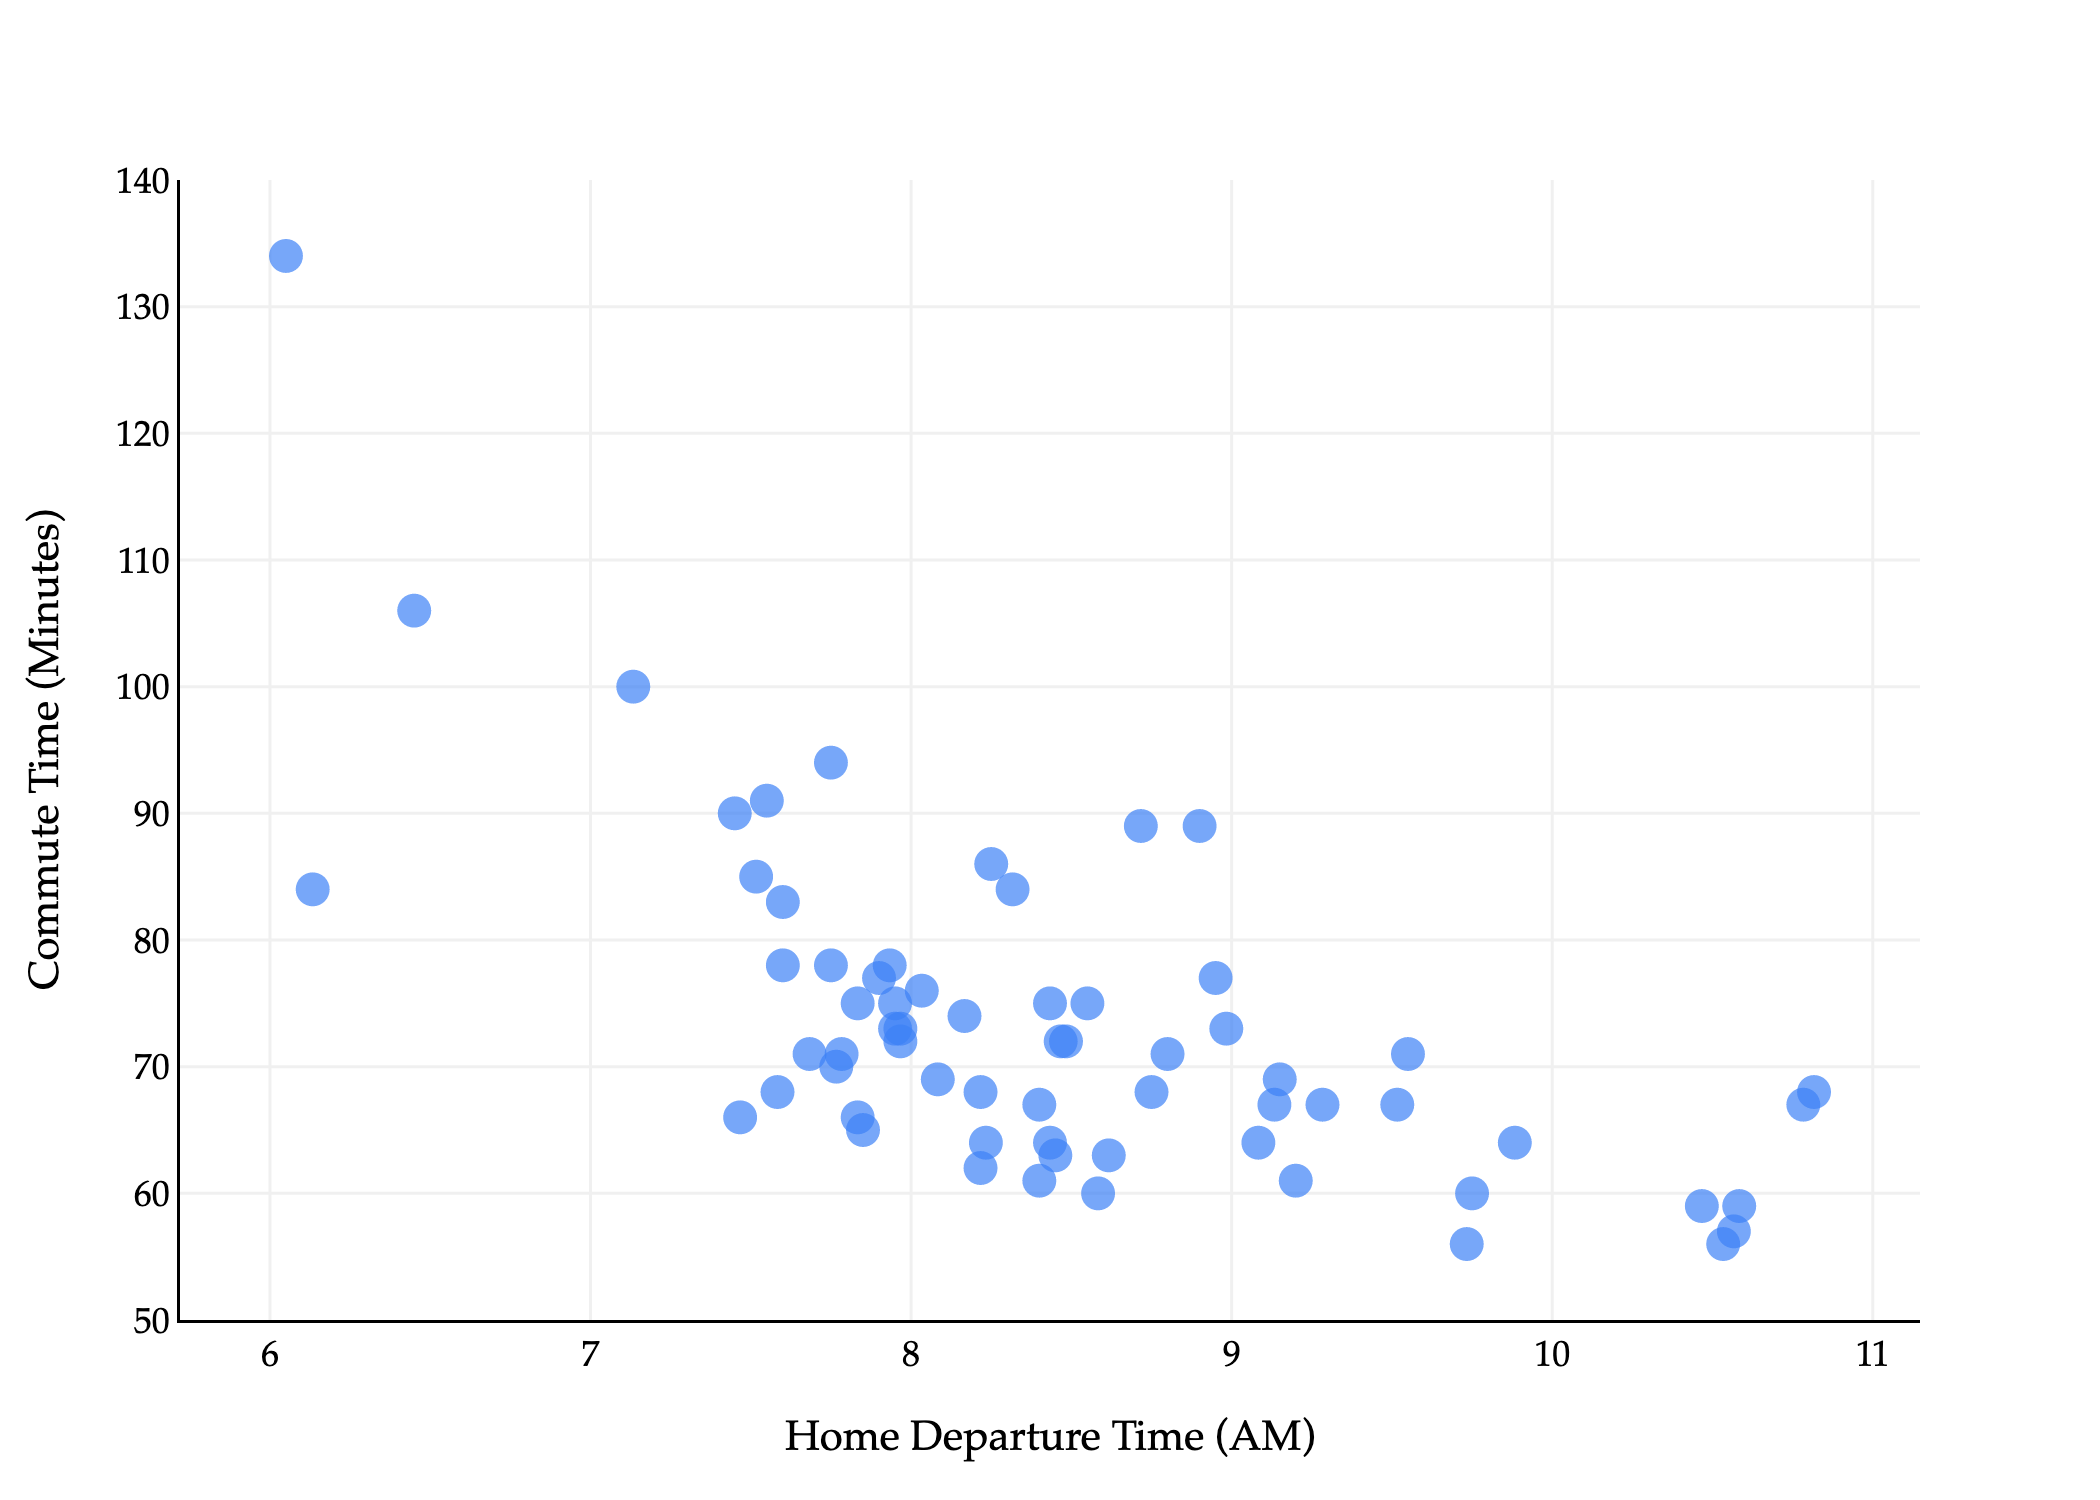

In [2]:
import pandas as pd
import numpy as np
import plotly.express as px

df = pd.read_csv('data/commute-times.csv')

fig = px.scatter(
    df,
    x='departure_hour',
    y='minutes',
    size=np.ones(len(df)) * 50,
    size_max=8
)
fig.update_xaxes(
    title='Home Departure Time (AM)',
    gridcolor='#f0f0f0',
    showline=True,
    linecolor="black",
    linewidth=1,
)
fig.update_yaxes(
    title='Commute Time (Minutes)',
    gridcolor='#f0f0f0',
    showline=True,
    linecolor="black",
    linewidth=1,
)
fig.update_traces(marker_color="#3D81F6", marker_line_width=0)
fig.update_layout(
    plot_bgcolor='white',
    paper_bgcolor='white',
    margin=dict(l=60, r=60, t=60, b=60),
    width=700,
    font=dict(
        family="Palatino Linotype, Palatino, serif",
        color="black"
    )
)
fig.show(renderer='png', scale=3)

That function was called a hypothesis function, denoted $h(x_i)$. Remember, the output of $h$ is a predicted $y$-value.

$$\text{predicted commute time}_i = h(\text{departure hour}_i)$$

We looked at two types of hypothesis function:

- The constant model, $h(x_i) = w$
- The simple linear regression model, $h(x_i) = w_0 + w_1 x_i$

We'll focus on the latter, which was first introduced in [Chapter 2.3](../02_simple_linear_regression/03-finding-optimal-parameters.ipynb). To find **optimal model parameters**, $w_0^*$ (the best intercept) and $w_1^*$ (the best slope), we followed the three-step modeling recipe:

**1. Choose a model.**
    $$h(x_i) = w_0 + w_1 x_i$$
**2. Choose a loss function.**
    Our default choice has been squared loss:
    $$L_\text{sq}(y_i, h(x_i)) = (y_i - h(x_i))^2$$

**3. Minimize average loss (also known as empirical risk) to find optimal parameters.**
Average _squared_ loss – also known as mean _squared_ error – for any hypothesis function $h$, takes the form:

$$\frac{1}{n} \sum_{i=1}^n (y_i - h(x_i))^2$$

For the simple linear regression model, this becomes:

$$R_\text{sq}(w_0, w_1) = \frac{1}{n} \sum_{i=1}^n (y_i - (w_0 + w_1 x_i))^2$$

In Chapter 2.3, we used calculus to minimize $R_\text{sq}(w_0, w_1)$ to find the optimal parameters, $w_0^*$ and $w_1^*$. This involved taking two partial derivatives, $\frac{\partial R_\text{sq}}{\partial w_0}$ and $\frac{\partial R_\text{sq}}{\partial w_1}$, setting them equal to zero, and solving the resulting system of equations. At the end of that process, we found

$$\underbrace{w_1^* = \frac{\sum_{i=1}^n (x_i - \bar x)(y_i - \bar y)}{\sum_{i=1}^n (x_i - \bar x)^2} = r \frac{\sigma_y}{\sigma_x}}_\text{optimal slope}, \quad \underbrace{w_0^* = \bar y - w_1^* \bar x}_\text{optimal intercept}$$

where $r$ is the correlation coefficient between $x$ and $y$, and $\sigma_x$ and $\sigma_y$ are the standard deviations of $x$ and $y$, respectively.

Those formulas, when applied to the dataset of commute times, describe the following <span style="color: orange; font-weight: bold;">line</span>.

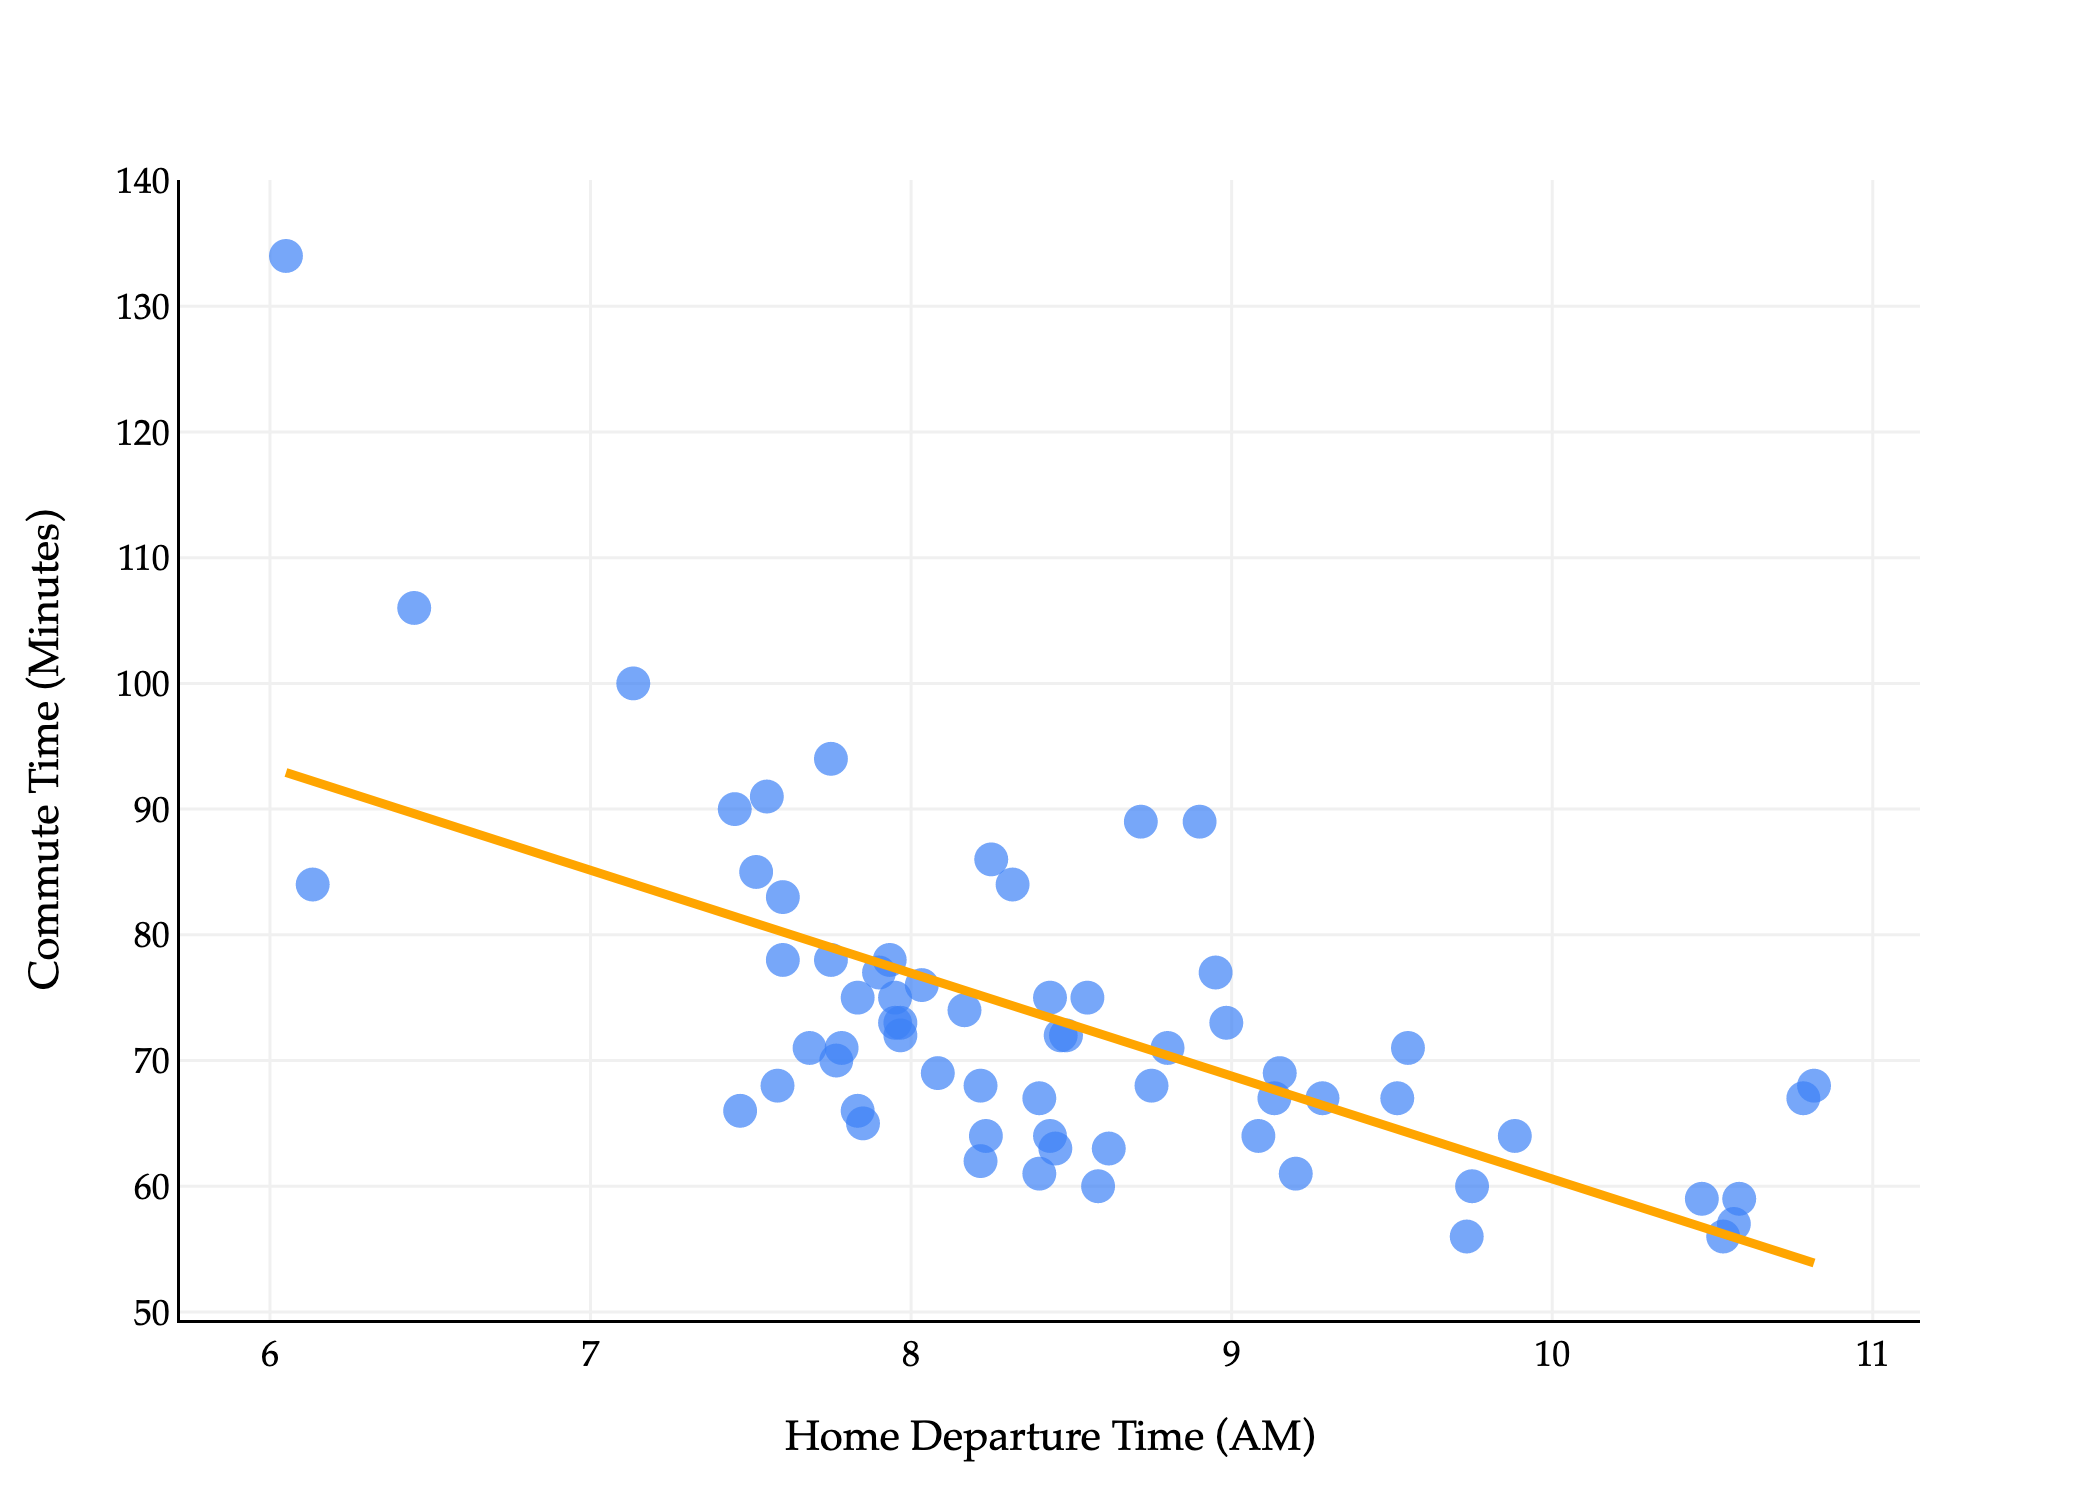

In [7]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

df = pd.read_csv('data/commute-times.csv')

# Compute means
x = df['departure_hour'].values
y = df['minutes'].values
x_bar = np.mean(x)
y_bar = np.mean(y)

# Compute slope (w1) and intercept (w0) using the closed-form solution
w1 = np.sum((x - x_bar) * (y - y_bar)) / np.sum((x - x_bar) ** 2)
w0 = y_bar - w1 * x_bar

# Prepare regression line points
x_line = np.array([x.min(), x.max()])
y_line = w0 + w1 * x_line

# Create scatter plot
fig = px.scatter(
    df,
    x='departure_hour',
    y='minutes',
    size=np.ones(len(df)) * 50,
    size_max=8
)
fig.update_traces(marker_color="#3D81F6", marker_line_width=0)

# Add regression line in orange
fig.add_traces(go.Scatter(
    x=x_line,
    y=y_line,
    mode='lines',
    line=dict(color='orange', width=3),
    name='Regression Line'
))

fig.update_xaxes(
    title='Home Departure Time (AM)',
    gridcolor='#f0f0f0',
    showline=True,
    linecolor="black",
    linewidth=1,
)
fig.update_yaxes(
    title='Commute Time (Minutes)',
    gridcolor='#f0f0f0',
    showline=True,
    linecolor="black",
    linewidth=1,
)
fig.update_layout(
    plot_bgcolor='white',
    paper_bgcolor='white',
    margin=dict(l=60, r=60, t=60, b=60),
    width=700,
    font=dict(
        family="Palatino Linotype, Palatino, serif",
        color="black"
    ),
    showlegend=False
)
scatter_fig = fig
scatter_fig.show(renderer='png', scale=3)

Here's the plan:
- In [Chapter 7.1](./01-regression-using-linear-algebra.ipynb) (that's here), we'll see another way to find $w_0^*$ and $w_1^*$ that **doesn't** involve calculus, but rather leverages our new knowledge of vectors and matrices.
- In [Chapter 7.2](./02-multiple-linear-regression.ipynb), we'll look at how to use this linear algebraic approach to add multiple input variables to our model. The <span style="color: orange; font-weight: bold;">orange line</span> above only uses one input variable, departure time, but we might want to incorporate day of the week, weather, etc.
- In homework, you will get a _taste_ of how to approach the process of adding new features, and why adding lots of features doesn't necessarily lead to better predictions on real-world, unseen data.

---

## The Design Matrix

**Big idea**: How can we express mean squared error,

$$R_\text{sq}(w_0, w_1) = \frac{1}{n} {\color{d81a60} \sum_{i=1}^n} \underbrace{(y_i - (w_0 + w_1 x_i))^{\color{d81a60}2}}_{({\text{actual} - \text{predicted}})^2}$$

in terms of vectors and matrices? If we can do so, then perhaps there will be another way to find $w_0^*$ and $w_1^*$ without needing to take partial derivatives. This will make our life a lot easier when we add more features to our model.

Remember that if $\vec x \in \mathbb{R}^n$, then $\lVert \vec x \rVert^2 = \sum_{i = 1}^n x_i^2$. In the formula for $R_\text{sq}$ above, I've colored $\color{d81a60}\sum_{i = 1}^n$ and $\cdot^{\color{d81a60}2}$ in red to try and make the case that **$R_\text{sq}$ looks a lot like the squared norm of vector that contains the errors of our predictions**. Let's try and define this vector.

Consider a dataset of $n$ points, $(x_1, y_1), (x_2, y_2), \ldots, (x_n, y_n)$, on which we'd like to fit a simple linear regression model $h(x_i) = w_0 + w_1 x_i$.

- The **observation vector**, $\color{orange} \vec y$, is a vector in $\mathbb{R}^n$ with the $n$ $y$-values from the dataset.

    $$\color{orange} {\vec y} = \begin{bmatrix} y_1 \\ y_2 \\ \vdots \\ y_n \end{bmatrix} = \underbrace{\begin{bmatrix} \text{actual commute time}_1 \\ \text{actual commute time}_2 \\ \vdots \\ \text{actual commute time}_n \end{bmatrix}}_{\text{for the commute times example}}$$

    This vector contains our "right answers" that we are trying to predict as best as we can.

- The **prediction vector**, $\color{#004d40} \vec p$, is a vector in $\mathbb{R}^n$ with the $n$ predicted values from the model.

    $${\color{#004d40} \vec p} = \begin{bmatrix} h(x_1) \\ h(x_2) \\ \vdots \\ h(x_n) \end{bmatrix} = \begin{bmatrix} w_0 + w_1 {\color{#3d81f6} x_1} \\ w_0 + w_1 {\color{#3d81f6} x_2} \\ \vdots \\ w_0 + w_1 {\color{#3d81f6} x_n} \end{bmatrix}$$

    We want $\color{#004d40} \vec p$ to be as close as possible to $\color{orange} \vec y$.

**We can express the prediction vector, $\color{#004d40} \vec p$, as a matrix-vector product!**

$${\color{#004d40} \vec p} = \begin{bmatrix} w_0 + w_1 {\color{#3d81f6} x_1} \\ w_0 + w_1 {\color{#3d81f6} x_2} \\ \vdots \\ w_0 + w_1 {\color{#3d81f6} x_n} \end{bmatrix} = w_0 \begin{bmatrix} 1 \\ 1 \\ \vdots \\ 1 \end{bmatrix} + w_1 \begin{bmatrix} \color{#3d81f6} x_1 \\ \color{#3d81f6} x_2 \\ \vdots \\ \color{#3d81f6} x_n \end{bmatrix} = \begin{bmatrix} 1 & \color{#3d81f6} x_1 \\ 1 & \color{#3d81f6} x_2 \\ \vdots & \vdots \\ 1 & \color{#3d81f6} x_n \end{bmatrix} \begin{bmatrix} w_0 \\ w_1 \end{bmatrix} = {\color{#3d81f6} X} \vec w$$

In $\color{#004d40} \vec p = {\color{#3d81f6} X} \vec w$,

- ${\color{#3d81f6} X}$, called the **design matrix**, is an $n \times 2$ matrix with its first column being all 1s and its second column being the inputs ${\color{#3d81f6} x_1, x_2, \ldots, x_n}$. It's the most important among these definitions, hence why this section is titled "The Design Matrix".

    $$\color{#3d81f6} X = \begin{bmatrix} 1 & x_1 \\ 1 & x_2 \\ \vdots & \vdots \\ 1 & x_n \end{bmatrix} = \underbrace{\begin{bmatrix} 1 & \text{departure time}_1 \\ 1 & \text{departure time}_2 \\ \vdots & \vdots \\ 1 & \text{departure time}_n \end{bmatrix}}_{\text{for the commute times example}}$$

    I haven't been able to find a good reason for why this is called the design matrix; my best explanation is that it has to do with how we designed our model. **The column of 1s is there for our intercept term, $w_0$.**

- The **parameter vector**, $\vec w$, is a $2 \times 1$ vector containing our model's parameters, $w_0$ and $w_1$.

    $$\vec w = \begin{bmatrix} w_0 \\ w_1 \end{bmatrix}$$

    We're trying to find the best choice of $\vec w$.

Remember, our goal is to convert

$$R_\text{sq}(w_0, w_1) = \frac{1}{n} \sum_{i=1}^n (y_i - (w_0 + w_1 x_i))^2$$

into an expression that involves vectors and matrices. Using our new definitions, we're almost there! $R_\text{sq}$ involves a sum of squared errors. So, let's define the **error vector**, $\color{d81a60} \vec e$, as the difference between $\color{orange} \vec y$ and ${\color{#004d40} \vec p} = {\color{#3d81f6} X} \vec w$.

$${\color{d81a60} \vec e} = {\color{orange} \vec y} - {\color{#004d40} \vec p} = {\color{orange} \vec y} - {{\color{#3d81f6} X} \vec w} = {\color{orange} \begin{bmatrix} y_1 \\ y_2 \\ \vdots \\ y_n \end{bmatrix}} - \begin{bmatrix} w_0 + w_1 {\color{#3d81f6} x_1} \\ w_0 + w_1 {\color{#3d81f6} x_2} \\ \vdots \\ w_0 + w_1 {\color{#3d81f6} x_n} \end{bmatrix} = \begin{bmatrix} {\color{orange} y_1} - (w_0 + w_1 {\color{#3d81f6} x_1}) \\ {\color{orange} y_2} - (w_0 + w_1 {\color{#3d81f6} x_2}) \\ \vdots \\ {\color{orange} y_n} - (w_0 + w_1 {\color{#3d81f6} x_n}) \end{bmatrix}$$

The components of $\color{d81a60} \vec e$ are the quantities being summed and squared in $R_\text{sq}$. How do we get that sum and square? By taking the norm, as I alluded to earlier.

$$\lVert {\color{d81a60} \vec e} \rVert^2 = \sum_{i=1}^n e_i^2 = \sum_{i=1}^n (y_i - (w_0 + w_1 x_i))^2$$

$\lVert {\color{d81a60} \vec e} \rVert^2$ is _almost_ $R_\text{sq}$, it's just missing a $\frac{1}{n}$ up front. So,

$$\boxed{R_\text{sq}(\vec w) = \frac{1}{n} \lVert {\color{d81a60} \vec e} \rVert^2 = \frac{1}{n} \lVert {\color{orange} \vec y} - {\color{#3d81f6} X} \vec w \rVert^2}$$

We've completed our "conversion" of $R_\text{sq}$ into a vector-based expression.

---

## The Normal Equations Return

Now, our goal is to find the vector $\vec w^*$ that minimizes

$$R_\text{sq}(\vec w) = \frac{1}{n} \lVert {\color{orange} \vec y} - {\color{#3d81f6} X} \vec w \rVert^2$$

This sounds like a familiar problem. ${\color{#3d81f6} X} \vec w$ is a vector in $\text{colsp}({\color{#3d81f6} X})$, so it looks like we want to find the vector in $\text{colsp}({\color{#3d81f6} X})$ that is closest to $\color{orange} \vec y$. The extra $\frac{1}{n}$ up front doesn't change the optimization problem; as we studied in our calculus review at the start of the semester (and in the examples in [Appendix 2](../00_math_foundations/02-derivatives.ipynb#maxima-and-minima)), the minimizer of $cf(w)$ is the same as the minimizer of $f(w)$ when $c > 0$.

**This is exactly the problem we solved in [Chapter 6.3](../06_linear_transformations_and_projections/03-projecting-onto-column-space.ipynb)!**

In [5]:
from utils import plot_vectors
import numpy as np
import plotly.graph_objects as go

y = np.array([1, 3, 2]) * 1.5
v1 = (1, 0, 0.25)
v2 = np.array([2, 2, 0]) * 0.5

def create_base_fig(show_spanners=True):
    # Define the vectors
    v3 = (-3.5 * v1[0] + 4 * v2[0], -3.5 * v1[1] + 4 * v2[1], -3.5 * v1[2] + 4 * v2[2])  # v3 is v1 + v2, which is on the plane spanned by v1 and v2

    # Plot the vectors using plot_vectors function
    vectors = [
        (tuple(y), "orange", "y"),
        (v1, "#3d81f6", "x⁽¹⁾"), 
        (tuple(-v2), "#3d81f6", "x⁽²⁾"),
        (v3, "#3d81f6", "x⁽³⁾")
    ]
    
    if not show_spanners:
        vectors = [vectors[0]]

    fig = plot_vectors(vectors, show_axis_labels=True, vdeltaz=5, vdeltax=1)

    # Make the plane look more rectangular by using a smaller, symmetric range for s and t
    plane_extent = 20  # controls the "size" of the rectangle
    num_points = 3   # fewer points for a cleaner rectangle

    s_range = np.linspace(-plane_extent, plane_extent, num_points)
    t_range = np.linspace(-plane_extent, plane_extent, num_points)
    s_grid, t_grid = np.meshgrid(s_range, t_range)

    plane_x = s_grid * v1[0] + t_grid * v2[0]
    plane_y = s_grid * v1[1] + t_grid * v2[1]
    plane_z = s_grid * v1[2] + t_grid * v2[2]

    fig.add_trace(go.Surface(
        x=plane_x,
        y=plane_y,
        z=plane_z,
        opacity=0.8,
        colorscale=[[0, 'rgba(61,129,246,0.3)'], [1, 'rgba(61,129,246,0.3)']],
        showscale=False,
    ))

    # Annotate the plane with "colsp(X)"
    # Move the annotation "down" the plane by choosing negative s and t values
    label_s = 0.3
    label_t = 0.9
    label_x = label_s * v1[0] + label_t * v2[0]
    label_y_coord = label_s * v1[1] + label_t * v2[1] - 2
    label_z = label_s * v1[2] + label_t * v2[2]

    fig.add_trace(go.Scatter3d(
        x=[4],
        y=[-2],
        z=[2],  # small offset above the plane for visibility
        mode="text",
        text=[r"colsp(X)"],
        textposition="middle center",
        textfont=dict(size=22, color="#3d81f6"),
        showlegend=False
    ))

    # Set equal ranges for all axes to make grid boxes square
    axis_range = [-3, 5]  # Same range for all axes
    
    fig.update_layout(
        scene_camera=dict(
            eye=dict(x=1, y=-1.3, z=1)
        ),
        scene=dict(
            xaxis=dict(
                range=axis_range,
                dtick=1,
            ),
            yaxis=dict(
                range=axis_range,
                dtick=1,
            ),
            zaxis=dict(
                range=axis_range,
                dtick=1,
            ),
            aspectmode="cube",
            aspectratio=dict(x=1, y=1, z=1),  # Explicitly set 1:1:1 ratio
        ),
    )
    return fig

def plot_vectors_with_errors(vectors_list, base_fig=None, notation="0"):
    """
    Takes a list of vectors and draws each one in #004d40 with a dotted error line in #d81a60.
    
    Parameters:
    -----------
    vectors_list : list of array-like
        List of vectors to plot. Each vector should be a 3D point/vector.
    base_fig : plotly.graph_objects.Figure, optional
        Base figure to build upon. If None, creates a new base figure using create_base_fig().
    
    Returns:
    --------
    fig : plotly.graph_objects.Figure
        The figure with vectors and error lines added.
    """
    fig = create_base_fig(show_spanners=False)
    
    # Get y vector from create_base_fig (defined the same way)
    y = np.array([1, 3, 2]) * 1.5
    
    for i, vec in enumerate(vectors_list):
        vec = np.array(vec)
        
        # Draw the vector in #004d40
        fig.add_trace(go.Scatter3d(
            x=[0, vec[0]],
            y=[0, vec[1]],
            z=[0, vec[2]],
            mode='lines',
            line=dict(color='#004d40', width=6),
            showlegend=False
        ))
        
        # Add arrowhead for the vector
        fig.add_trace(go.Cone(
            x=[vec[0]],
            y=[vec[1]],
            z=[vec[2]],
            u=[vec[0]],
            v=[vec[1]],
            w=[vec[2]],
            colorscale=[[0, '#004d40'], [1, '#004d40']],
            showscale=False,
            sizemode="absolute",
            sizeref=0.3,
            showlegend=False
        ))
        
        # Draw the error line (dotted) from vec to y in #d81a60
        fig.add_trace(go.Scatter3d(
            x=[vec[0], y[0]],
            y=[vec[1], y[1]],
            z=[vec[2], y[2]],
            mode='lines',
            line=dict(color='#d81a60', width=4, dash='dash'),
            showlegend=False
        ))

        # Annotate the vectors and error lines
        if i == 0:
            # Annotate the vector as Xw₀
            fig.add_trace(go.Scatter3d(
                x=[1], y=[3], z=[-0.5],
                mode='text',
                text=["p\u2080 = Xw\u2080"] if notation == "0" else ["p = Xw*"],  # \u2080 is Unicode subscript zero
                textposition="middle center",
                textfont=dict(color='#004d40', size=16),
                showlegend=False
            ))
            # Annotate the error as e₀
            mid_error = (vec + y) / 2
            fig.add_trace(go.Scatter3d(
                x=[mid_error[0]],
                y=[mid_error[1]],
                z=[mid_error[2]],
                mode='text',
                text=["e\u2080"] if notation == "0" else ["e"],
                textposition="bottom center",
                textfont=dict(color='#d81a60', size=16),
                showlegend=False
            ))
        else:
            # Annotate the vector as Xw'
            fig.add_trace(go.Scatter3d(
                x=[2], y=[-1], z=[1],
                mode='text',
                text=["p' = Xw'"],
                textposition="middle center",
                textfont=dict(color='#004d40', size=16),
                showlegend=False
            ))
            # Annotate the error as e'
            mid_error = (vec + y) / 2
            fig.add_trace(go.Scatter3d(
                x=[mid_error[0]],
                y=[mid_error[1]],
                z=[mid_error[2]],
                mode='text',
                text=["e'"],
                textposition="bottom center",
                textfont=dict(color='#d81a60', size=16),
                showlegend=False
            ))
    
    return fig

# fig = create_base_fig()

# y = np.array([1, 3, 2]) * 1.5
# v1 = (1, 0, 0.25)
# v2 = np.array([2, 2, 0]) * 0.5

X = np.vstack([v1, v2]).T
w = np.linalg.inv(X.T @ X) @ X.T @ y
# w = [-1.333, 3.6667]
p = X @ w
test_vectors = [p]

# Plot vectors with errors and draw a right angle between p and e
norm_fig = plot_vectors_with_errors(test_vectors, fig, notation='*')
norm_fig.show()

In Chapter 6.3, we found that the vector in $\text{colsp}({\color{#3d81f6} X})$ that is closest to $\color{orange} \vec y$ is the **orthogonal projection** of $\color{orange} \vec y$ onto $\text{colsp}({\color{#3d81f6} X})$, which is the vector

$${\color{#004d40} \vec p} = {\color{#3d81f6} X} \vec w^*$$

where $\vec w^*$ is chosen to satisfy the **normal equation**,

$${\color{#3d81f6} X^T X} \vec w^* = {\color{#3d81f6} X^T} \color{orange} \vec y$$

Note that both **p**rojection and **p**rediction start with "p", making it easy to remember that they're related, and the vector ${\color{#004d40} \vec p}$ can be interpreted as either. Predictions are projections onto the column space of the design matrix.

What makes the projection "orthogonal" is that the projection ${\color{#004d40} \vec p} = {\color{#3d81f6} X} \vec w^*$ has an error vector ${\color{d81a60} \vec e} = {\color{orange} \vec y} - {\color{#3d81f6} X} \vec w^*$ that is orthogonal to every vector in $\text{colsp}({\color{#3d81f6} X})$.

$${\color{#3d81f6} X^T} {\color{d81a60} \vec e} = \vec 0$$

When $\color{#3d81f6} X$'s columns are linearly independent, then $\color{#3d81f6} X^TX$ is invertible, and the unique solution $\vec w^*$ to the normal equation is

$$\vec w^* = ({\color{#3d81f6} X^T X})^{-1} {\color{#3d81f6} X^T} \color{orange} \vec y$$

The vector $\vec w^*$, in this context, is called our **optimal parameter vector**, since it contains our optimal choices of parameters, $w_0^*$ and $w_1^*$. Note that

$$\color{#3d81f6} X = \begin{bmatrix} 1 & x_1 \\ 1 & x_2 \\ \vdots & \vdots \\ 1 & x_n \end{bmatrix}$$

is invertible as long as **not** all of the $x_i$'s are the same. If they are all the same, then $\color{#3d81f6} X$'s second column is a multiple of its first column, and so $\color{#3d81f6} X$ is not of full rank, and neither is $\color{#3d81f6} X^TX$ (since both matrices have the same rank). This corresponds to the case where the data points all lie on a single **vertical** line, so no line of the form $h(x_i) = w_0^* + w_1^* x_i$ can pass through them.

So, to summarize,

$$R_\text{sq}(\vec w) = \frac{1}{n} \lVert {\color{orange} \vec y} - {\color{#3d81f6} X} \vec w \rVert^2$$

is minimized when

$${\color{#3d81f6} X^TX} \vec w^* = {\color{#3d81f6} X^T} {\color{orange}\vec y} \implies \underbrace{\vec w^* = ({\color{#3d81f6} X^T X})^{-1} {\color{#3d81f6} X^T} {\color{orange} \vec y}}_{\text{ if } {\color{#3d81f6} X} \text{'s columns are linearly independent}}$$

To be clear, when $\color{#3d81f6} X$ is the $n \times 2$ design matrix and $\color{orange} \vec y$ is a vector with our $n$ $y$-values, then $\vec w^*$ as defined above contains **the exact same values as** our calculus-based formulas for $w_0^*$ and $w_1^*$!

### Errors Sum to 0

Since the first column of the design matrix $X$ is a column of all 1s, the condition ${\color{#3d81f6} X^T}{\color{d81a60}\vec e} = \vec 0$ tells us that the error vector ${\color{d81a60}\vec e}$ must be orthogonal to $\begin{bmatrix} 1 \\ 1 \\ \vdots \\ 1 \end{bmatrix}$. That means

$$\begin{bmatrix} 1 \\ 1 \\ \vdots \\ 1 \end{bmatrix} \cdot {\color{d81a60} \begin{bmatrix} e_1 \\ e_2 \\ \vdots \\ e_n \end{bmatrix}} = {\color{d81a60}e_1} + {\color{d81a60}e_2} + \cdots + {\color{d81a60}e_n} = 0$$ 

So, for a fit simple linear regression model with an intercept term, the components of the error vector are guaranteed to sum to 0. This is worth caring about because it gives us a concrete constraint that our best fit model must satisfy: some errors may be positive and some negative, but overall they must balance out exactly.

In [Chapter 7.2](./02-multiple-linear-regression.ipynb), we'll explore the process of introducing additional features to our models. In that process, we might sometimes choose to build a model without an intercept term. If we do, then the design matrix no longer has to contain a column of all 1s, and this guarantee no longer has to hold. So this is not a universal fact about every linear model; it is a consequence of fitting by least squares **and** including an intercept term.

---

## Implementing $\vec w^*$ in Code

While you may have to wait until you complete Homework 7 to see a proof that

$$\vec w^* = ({\color{#3d81f6} X^T X})^{-1} {\color{#3d81f6} X^T} {\color{orange} \vec y} = \begin{bmatrix} \bar{y} - r \frac{\sigma_y}{\sigma_x} \bar{x} \\ r \frac{\sigma_y}{\sigma_x} \end{bmatrix}$$

I think it's worthwhile for me to give you a preview that these are equivalent, through the lens of code. The `commutes` DataFrame in `pandas`, stored below, contains our commute times data. The first column, `departure_hour`, is our $x$-variable, while `minutes` is

In [17]:
commutes = df[['departure_hour', 'minutes']]

In [18]:
commutes

,departure_hour,minutes
0,10.816667,68.0
1,7.750000,94.0
2,8.450000,63.0
3,7.133333,100.0
4,9.150000,69.0
...,...,...
60,7.516667,85.0
61,7.550000,91.0
62,7.583333,68.0
63,7.450000,90.0


### Approach 1: The Old Formulas

We've done this before, but let's implement our original formulas for $w_0^*$ and $w_1^*$ in code.

$$w_1^* = \frac{\sum_{i=1}^n (x_i - \bar x)(y_i - \bar y)}{\sum_{i=1}^n (x_i - \bar x)^2} = r \frac{\sigma_y}{\sigma_x}, \quad w_0^* = \bar y - w_1^* \bar x$$

In [19]:
def optimal_slope(x, y):
    r = np.corrcoef(x, y)[0, 1]
    return r * np.std(y) / np.std(x)

optimal_slope(commutes['departure_hour'], commutes['minutes'])

-8.186941724265557

In [20]:
def optimal_intercept(x, y):
    return np.mean(y) - optimal_slope(x, y) * np.mean(x)

optimal_intercept(commutes['departure_hour'], commutes['minutes'])

142.44824158772875

To actually use these optimal parameters to make predictions, we need to execute $w_0^* + w_1^* x_i$ ourselves.

In [27]:
def predicted_commute(departure_hour):
    w0_star = optimal_intercept(commutes['departure_hour'], commutes['minutes'])
    w1_star = optimal_slope(commutes['departure_hour'], commutes['minutes'])
    return w0_star + w1_star * departure_hour

predicted_commute(15)

19.644115723745387

### Approach 2: The Normal Equations

Now, we'll use the fact that

$$\vec w^* = ({\color{#3d81f6} X^T X})^{-1} {\color{#3d81f6} X^T} {\color{orange} \vec y}$$

to find the optimal slope and intercept. Remember, [Chapter 6.2](../06_linear_transformations_and_projections/02-inverses.ipynb#computing-the-inverse-in-code) told us that it's generally a bad idea to use `np.linalg.inv` directly; instead, we should use `np.linalg.solve` to solve the normal equations.

In [24]:
# We need to make the n x 2 design matrix X, which has a column of 1's
# to account for the intercept.
commutes.loc[:, '1'] = 1
commutes[['1', 'departure_hour']]

,1,departure_hour
0,1,10.816667
1,1,7.750000
2,1,8.450000
3,1,7.133333
4,1,9.150000
...,...,...
60,1,7.516667
61,1,7.550000
62,1,7.583333
63,1,7.450000


In [25]:
X = commutes[['1', 'departure_hour']]
y = commutes['minutes']

w_star = np.linalg.solve(X.T @ X, X.T @ y)
w_star

array([142.44824159,  -8.18694172])

`w_star` contains the same values as our calculus-based formulas for $w_0^*$ and $w_1^*$ from above!

To use `w_star` to make predictions, we eventually need to evaluate $w_0^* + w_1^* x_i$, but it turns out this can be expressed as a **dot product** between $\vec w^*$ and $\begin{bmatrix} 1 \\ x_i \end{bmatrix}$. More on this in Chapter 7.2.

In [29]:
# Same as w0_star + w1_star * 15
np.dot(w_star, np.array([1, 15]))

19.644115723744356

In [30]:
# Also the same
w_star @ np.array([1, 15])

19.644115723744356


### Approach 3: `sklearn`

Finally, we can use `sklearn`'s `LinearRegression` class to find $w_0^*$ and $w_1^*$.

In [32]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

# By default, sklearn knows to minimize mean squared error,
# and knows to add an intercept term to the model.
# If you want to turn off the intercept, you can set `fit_intercept=False`.
model.fit(commutes[['departure_hour']].to_numpy(), commutes['minutes'].to_numpy())

print(model.intercept_, model.coef_)

142.4482415877287 [-8.18694172]


Once again, we get the same values as the prior two approaches! None of this should be a surprise, but it's reassuring to see that (1) our calculus and linear algebra approaches are consistent, and (2) both of those are equivalent to using `sklearn`. All three approaches involve the same three step modeling recipe.

And finally, to use `model` to make predictions, we don't need to do any of the math ourselves: we can use the `predict` method.

In [34]:
# The same, once again!
# Notice that the input is a 2D array.
# More on this in Chapter 7.2.
model.predict([[15]])

array([19.64411572])

---

## The Three Pictures

Throughout Chapter 2.3 and here in Chapter 7.1, we've seen three different diagrams involving the simple linear regression model, and it's important to understand what each one depicts.

### Picture 1: The Data and Model ($\mathbb{R}^2$)

The first and most intuitive diagram is the one that shows the original points $(x_1, y_1), (x_2, y_2), \ldots, (x_n, y_n)$ in $\mathbb{R}^2$ with the fit line $h(x_i) = w_0^* + w_1^* x_i$.

In the scatter plot below, the vertical errors from the fitted line – some of which are positive, some of which are negative – add up to 0, as we discussed in the section above titled [Errors Sum to 0](#errors-sum-to-0).

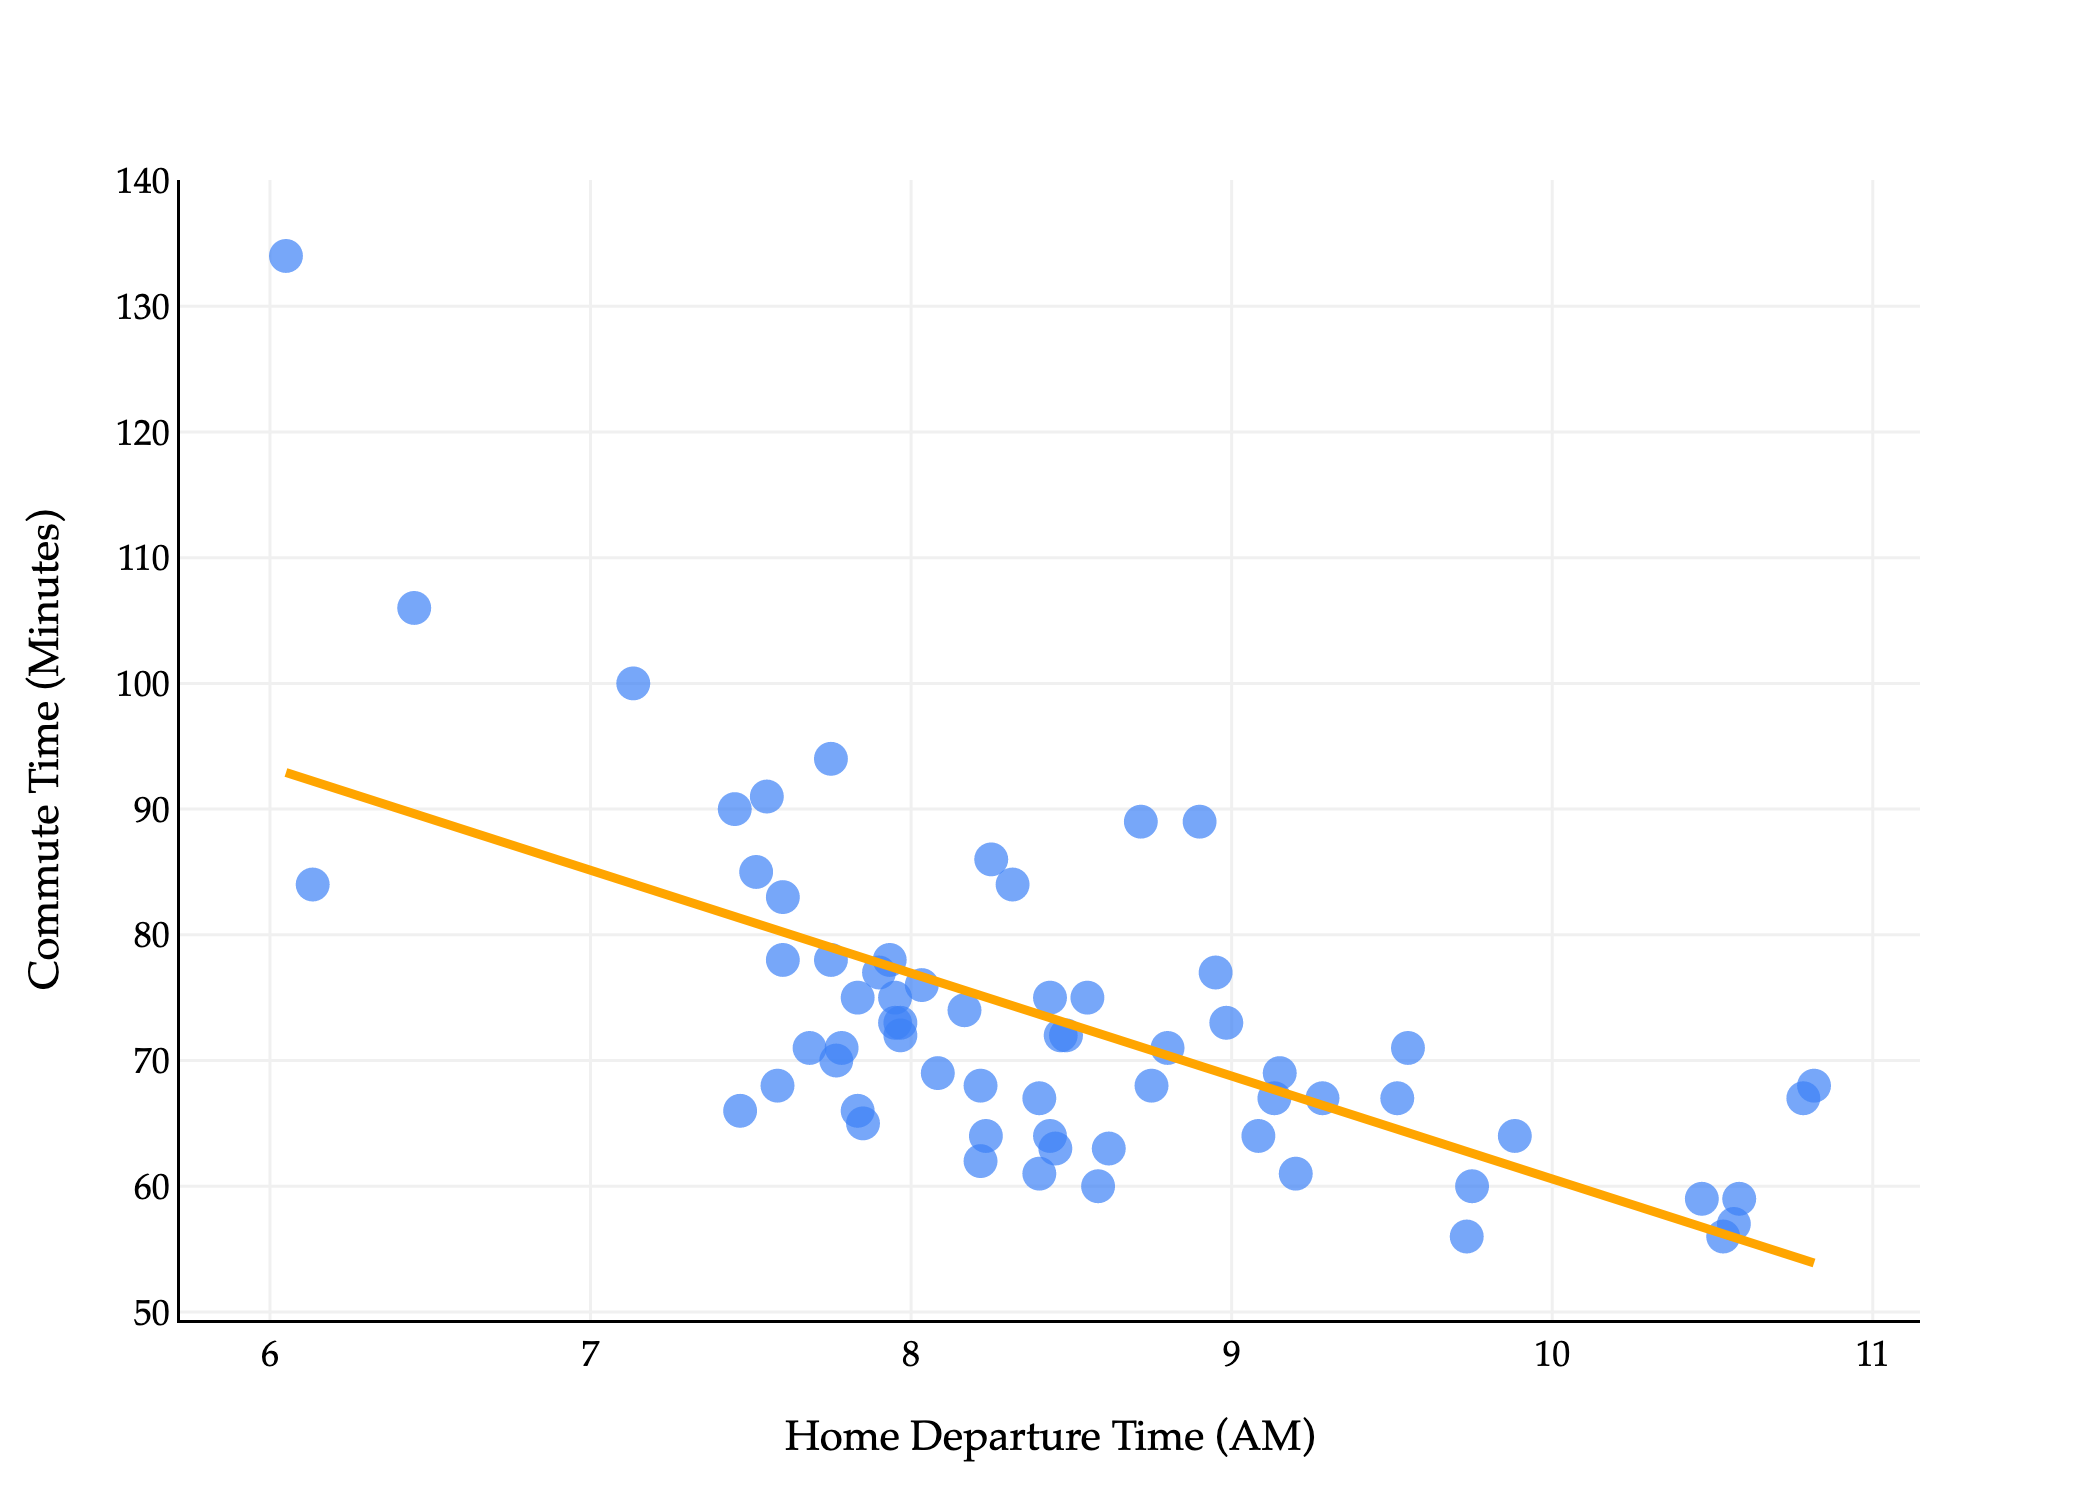

In [8]:
scatter_fig.show(renderer='png', scale=3)

### Picture 2: The Projection View ($\mathbb{R}^n$)

Then, there is the diagram that shows that the optimal predictions, ${\color{#004d40} \vec p} = {\color{#3d81f6} X} \vec w^*$, are the orthogonal projections of $\color{orange} \vec y$ onto $\text{colsp}({\color{#3d81f6} X})$. Unlike the above plot, which is in $\mathbb{R}^2$, this one is in $\mathbb{R}^n$, where $n$ is our number of data points.

In [11]:
norm_fig.show()

### Picture 3: The Loss Surface ($\mathbb{R}^3$)

The final relevant picture is that of the graph of mean squared error, i.e. the graph whose $x$-axis is $\vec w_0$, $y$-axis is $\vec w_1$, and whose $z$-axis is $R_\text{sq}(\vec w)$. The $w_0$ and $w_1$ coordinates of the "bottom" of the graph correspond to the optimal parameters in $\vec w^*$, which are the weights in the linear combination of the columns of $\color{#3d81f6} X$ that is closest to $\color{orange} \vec y$.

In [13]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go

def slope(x, y):
    # Assume x and y are two Series.
    numerator = ((x - np.mean(x)) * (y - np.mean(y))).sum()
    denominator = ((x - np.mean(x)) ** 2).sum()
    return numerator / denominator

def intercept(x, y):
    return y.mean() - slope(x, y) * x.mean()

df = pd.read_csv('data/commute-times.csv')

w0_star = intercept(df['departure_hour'], df['minutes'])
w1_star = slope(df['departure_hour'], df['minutes'])

def mse(y_actual, y_pred):
    return np.mean((y_actual - y_pred)**2)

def mse_for_departure_model(w):
    w0, w1 = w
    return mse(df['minutes'], w0 + w1 * df['departure_hour'])

num_points = 50 # increase for better resolution, but it will run more slowly. 
uvalues = np.linspace(120, 160, num_points)
vvalues = np.linspace(-13, -3, num_points)
(u, v) = np.meshgrid(uvalues, vvalues)
thetas = np.vstack((u.flatten(), v.flatten()))
MSE = np.array([mse_for_departure_model(t) for t in thetas.T])
loss_surface = go.Surface(
    x=u, y=v, z=np.reshape(MSE, u.shape),
    colorscale='PuRd',
    showscale=False,
    opacity=1,
    hovertemplate="w₀: %{x}<br>w₁: %{y}<br>R(w₀, w₁): %{z}<extra></extra>"
)
minimizer = go.Scatter3d(
    x=[w0_star], y=[w1_star], z=[mse_for_departure_model([w0_star, w1_star])],
    mode='markers', name='optimal parameters',
    marker=dict(size=10, color='gold'),
    hovertemplate="w₀: %{x}<br>w₁: %{y}<br>R(w₀, w₁): %{z}<extra></extra>"
)
fig = go.Figure(data=[loss_surface, minimizer])

fig.update_layout(
    scene=dict(
        xaxis=dict(
            title="w₀",
            backgroundcolor="white",
            gridcolor="#f0f0f0",
            showbackground=True,
            showline=True,
            linecolor="black",
            linewidth=1,
        ),
        yaxis=dict(
            title="w₁",
            backgroundcolor="white",
            gridcolor="#f0f0f0",
            showbackground=True,
            showline=True,
            linecolor="black",
            linewidth=1,
        ),
        zaxis=dict(
            title="R(w₀, w₁)",
            backgroundcolor="white",
            gridcolor="#f0f0f0",
            showbackground=True,
            showline=True,
            linecolor="black",
            linewidth=1,
        ),
        bgcolor="white"
    ),
    paper_bgcolor='white',
    plot_bgcolor='white',
    margin=dict(l=30, r=30, t=30, b=30),
    autosize=True,
    width=600,
    height=400,
    font=dict(
        family="Palatino Linotype, Palatino, serif",
        color="black"
    ),
    scene_camera=dict(
        eye=dict(x=-1.5, y=1.5, z=1.0)
    ),
)

fig.show(scale=4)

You should take time to understand how these are all related.
- Our goal is to find the best fitting line in Picture 1.
- To do that, we minimize mean squared error in Picture 3.
- To do that, we project $\color{orange} \vec y$ onto $\text{colsp}({\color{#3d81f6} X})$ in Picture 2.

With this in mind, let's move to [Chapter 7.2](./02-multiple-linear-regression.ipynb), where we'll see how to extend our new linear algebraic approach to multiple input variables, in what's called **multiple linear regression**.